In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# -------------------------
# Style
# -------------------------
sns.set_theme(style="white", context="paper")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.linewidth": 1.0,
})


# -------------------------
# Project paths
# -------------------------
# The Jupyter Notebook working directory should be:
# Code/Figures Python
project_dir = Path.cwd()

data_dir = project_dir / "Data"
results_dir = project_dir / "Results"


# -------------------------
# Input and output paths
# -------------------------
file = (
    data_dir
    / "MSA_PFF_Dropout_50p_1000times_Robustness_Test.xlsx"
)

base_out = (
    results_dir
    / "MSA_PFF_Dropout_50p_1000times_Robustness_Test"
)

base_out.mkdir(parents=True, exist_ok=True)

# Output folder for CCC histograms
out_dir = base_out / "CCC"
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Colors
# -------------------------
MSA_COLOR = "#9BBCE5"   # light blue
PFF_COLOR = "#F2C29B"   # light orange

MSA_DARK = "#4C72B0"    # MSA original-value marker
PFF_DARK = "#DD8452"    # PFF original-value marker

LINE_COLOR = "#2C3E50"  # original CCC line
P95_COLOR = "#D55E00"   # 95th-percentile line


# -------------------------
# Original CCCs
# -------------------------
orig_ccc_pff = 0.647501625247243
orig_ccc_msa = 0.395649442591783


# -------------------------
# CCC histogram helper
# -------------------------
def plot_dropout_ccc(
    df,
    title,
    hist_color,
    orig_ccc,
    save_prefix,
    bins=25,
    kde=True
):
    """
    Plot the CCC distribution from 1000 dropout repetitions.

    The original model CCC is shown as a solid vertical line, and the
    95th percentile of the dropout distribution is shown as a dashed line.
    """
    ccc_vals = df["CCC"].to_numpy(dtype=float)
    ccc_vals = ccc_vals[np.isfinite(ccc_vals)]

    p95 = np.percentile(ccc_vals, 95)

    fig, ax = plt.subplots(figsize=(5.0, 3.8))

    # Histogram using raw counts
    ax.hist(
        ccc_vals,
        bins=bins,
        density=False,
        color=hist_color,
        alpha=0.65,
        edgecolor="white",
        linewidth=0.8
    )

    # Optional KDE curve
    # if kde:
    #     sns.kdeplot(
    #         ccc_vals,
    #         ax=ax,
    #         linewidth=1.6,
    #         color=hist_color
    #     )

    # Original full-model CCC
    line_orig = ax.axvline(
        orig_ccc,
        color=LINE_COLOR,
        linewidth=2.2,
        linestyle="-",
        zorder=10
    )

    # 95th percentile of dropout results
    line_p95 = ax.axvline(
        p95,
        color=P95_COLOR,
        linewidth=2.0,
        linestyle="--",
        zorder=9
    )

    ax.set_title(title)
    ax.set_xlabel("Model performance (CCC)")
    ax.set_ylabel("Count")

    ax.legend(
        handles=[line_orig, line_p95],
        labels=[
            f"Original CCC = {orig_ccc:.3f}",
            f"95th percentile = {p95:.3f}"
        ],
        frameon=False,
        loc="upper right"
    )

    # Show only the left and bottom axes
    sns.despine(
        ax=ax,
        top=True,
        right=True,
        left=False,
        bottom=False
    )

    ax.tick_params(
        axis="both",
        which="major",
        bottom=True,
        left=True,
        direction="out",
        length=4,
        width=1.0,
        colors="k"
    )

    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    plt.tight_layout()

    fig.savefig(
        out_dir / f"{save_prefix}.pdf",
        bbox_inches="tight"
    )

    fig.savefig(
        out_dir / f"{save_prefix}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


# -------------------------
# Load MSA and PFF sheets
# -------------------------
df_msa = pd.read_excel(
    file,
    sheet_name="MSA",
    header=0
)

df_pff = pd.read_excel(
    file,
    sheet_name="PFF",
    header=0
)




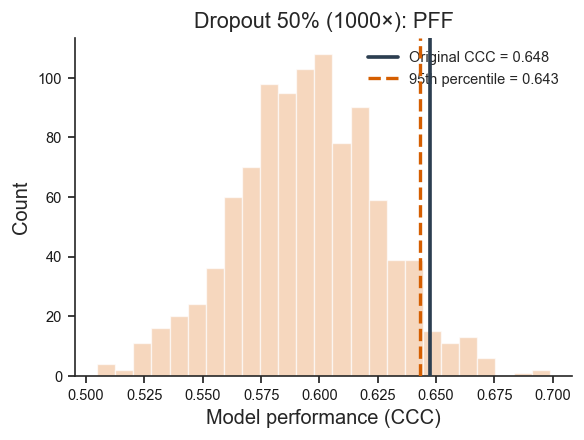

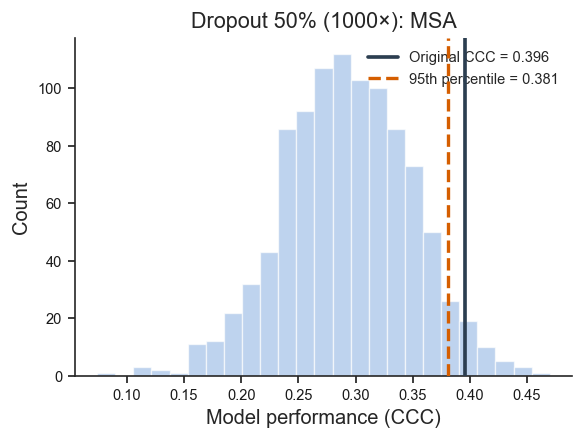

In [13]:
# -------------------------
# Plot CCC distributions
# -------------------------
plot_dropout_ccc(
    df=df_pff,
    title="Dropout 50% (1000×): PFF",
    hist_color=PFF_COLOR,
    orig_ccc=orig_ccc_pff,
    save_prefix="Dropout50_PFF_CCC_hist",
    bins=25,
    kde=True
)

plot_dropout_ccc(
    df=df_msa,
    title="Dropout 50% (1000×): MSA",
    hist_color=MSA_COLOR,
    orig_ccc=orig_ccc_msa,
    save_prefix="Dropout50_MSA_CCC_hist",
    bins=25,
    kde=True
)

In [5]:
# ============================================================
# From here to bottom: draw parameter violin plots
# ============================================================

# -------------------------
# Style
# -------------------------
sns.set_theme(style="white", context="paper")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.linewidth": 1.0,
})


# -------------------------
# Sheet names
# -------------------------
sheet_msa = "MSA"
sheet_pff = "PFF"


# -------------------------
# Reload data
# -------------------------
df_msa = pd.read_excel(
    file,
    sheet_name=sheet_msa,
    header=0
)

df_pff = pd.read_excel(
    file,
    sheet_name=sheet_pff,
    header=0
)

# Remove possible leading or trailing spaces from column names
df_msa.columns = df_msa.columns.astype(str).str.strip()
df_pff.columns = df_pff.columns.astype(str).str.strip()


# -------------------------
# Parameter column mapping
# -------------------------
PARAMS = {
    "gamma_seeding": {
        "col": "gamma_seeding",
        "xlabel": "Seeding rate (γ)"
    },
    "alpha_amplification": {
        "col": "alpha_amplification",
        "xlabel": "Amplification (α)"
    },
    "beta_spreading": {
        "col": "beta_spreading",
        "xlabel": "Spreading rate (β)"
    },
    "s_directionality": {
        "col": "s_directionality",
        "xlabel": "Directionality (s)"
    },
}


# -------------------------
# Original full-model parameters
# -------------------------
# The previous GCI parameter values are now labeled as MSA.
ORIG = {
    "gamma_seeding": {
        "MSA": 3.33011589059737E-06,
        "PFF": 0.00573578142606622
    },
    "alpha_amplification": {
        "MSA": 4.39076023181626,
        "PFF": 0.289010231938832
    },
    "beta_spreading": {
        "MSA": 0.189040999286407,
        "PFF": 0.11291086053244
    },
    "s_directionality": {
        "MSA": 0.0,
        "PFF": 0.844337160484113
    },
}


# -------------------------
# Build a long-format dataframe
# -------------------------
def make_long_for_param(param_col, fix_s=False):
    """
    Combine one MSA parameter column and one PFF parameter column into
    a long-format dataframe for seaborn plotting.
    """
    msa = df_msa[[param_col]].copy()
    pff = df_pff[[param_col]].copy()

    msa["Group"] = "MSA"
    pff["Group"] = "PFF"

    msa = msa.rename(columns={param_col: "Value"})
    pff = pff.rename(columns={param_col: "Value"})

    long = pd.concat(
        [msa, pff],
        ignore_index=True
    )

    long["Value"] = pd.to_numeric(
        long["Value"],
        errors="coerce"
    )

    # Remove missing or nonnumeric values
    long = long.dropna(subset=["Value"]).copy()

    # Clamp tiny negative directionality values to zero
    if fix_s:
        long.loc[long["Value"] < 0, "Value"] = 0.0

    # Keep MSA on the left and PFF on the right
    long["Group"] = pd.Categorical(
        long["Group"],
        categories=["MSA", "PFF"],
        ordered=True
    )

    return long


# -------------------------
# Violin plot for parameters on the original scale
# -------------------------
def plot_param_violin(param_key):
    param_col = PARAMS[param_key]["col"]
    xlabel = PARAMS[param_key]["xlabel"]

    fix_s = param_key == "s_directionality"

    long = make_long_for_param(
        param_col,
        fix_s=fix_s
    )

    # Create a separate output folder for each parameter
    param_out_dir = base_out / param_key
    param_out_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(4.2, 3.8))

    # Full violin distributions
    sns.violinplot(
        data=long,
        x="Group",
        y="Value",
        order=["MSA", "PFF"],
        palette={
            "MSA": MSA_COLOR,
            "PFF": PFF_COLOR
        },
        inner=None,
        cut=0,
        linewidth=0.9,
        bw_adjust=0.7,
        scale="width",
        width=0.72,
        ax=ax
    )

    # Make violin fills slightly transparent
    for coll in ax.collections:
        try:
            coll.set_alpha(0.55)
        except Exception:
            pass

    # Mean and standard deviation for each group
    summary_stats = (
        long.groupby("Group", observed=False)["Value"]
        .agg(
            mean="mean",
            sd=lambda x: np.std(x, ddof=1)
        )
        .reindex(["MSA", "PFF"])
    )

    xs = np.arange(len(summary_stats))

    ax.errorbar(
        xs,
        summary_stats["mean"].to_numpy(),
        yerr=summary_stats["sd"].to_numpy(),
        fmt="o",
        markersize=4.5,
        color="k",
        ecolor="#555555",
        elinewidth=1.2,
        capsize=4,
        capthick=1.2,
        zorder=20
    )

    # Original parameter values from the model fitted without dropout
    orig_msa = ORIG[param_key]["MSA"]
    orig_pff = ORIG[param_key]["PFF"]

    ax.plot(
        [-0.18, 0.18],
        [orig_msa, orig_msa],
        color=MSA_DARK,
        linewidth=2.4,
        solid_capstyle="round",
        zorder=10
    )

    ax.plot(
        [0.82, 1.18],
        [orig_pff, orig_pff],
        color=PFF_DARK,
        linewidth=2.4,
        solid_capstyle="round",
        zorder=10
    )

    ax.set_xlabel("")
    ax.set_ylabel(xlabel)

    sns.despine(
        ax=ax,
        top=True,
        right=True,
        left=False,
        bottom=False
    )

    ax.tick_params(
        axis="both",
        which="major",
        bottom=True,
        left=True,
        direction="out",
        length=4,
        width=1.0,
        colors="k"
    )

    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    ax.set_title(
        f"Dropout 50% (1000×): {param_key}"
    )

    plt.tight_layout()

    fig.savefig(
        param_out_dir
        / f"{param_key}_violin_MSA_vs_PFF.pdf",
        bbox_inches="tight"
    )

    fig.savefig(
        param_out_dir
        / f"{param_key}_violin_MSA_vs_PFF.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)



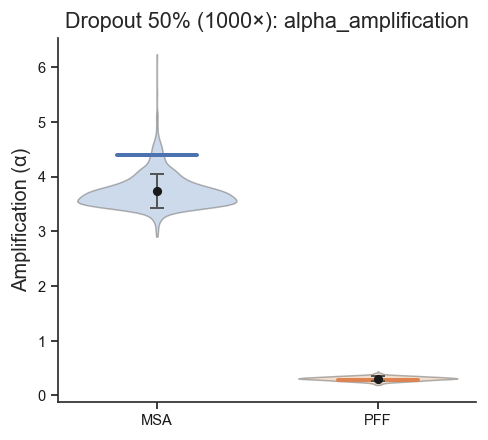

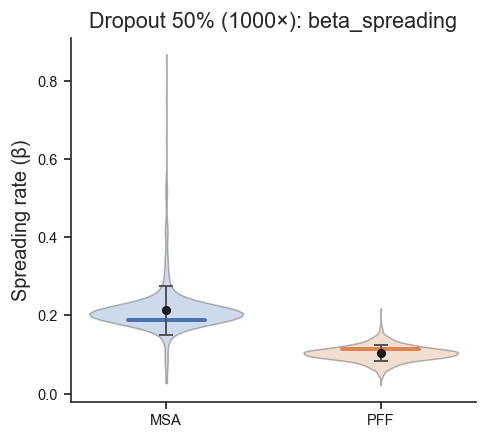

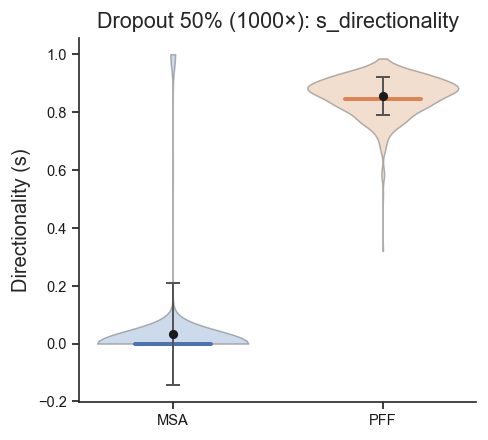

In [6]:
# -------------------------
# Plot original-scale parameters
# -------------------------
for k in [
    "alpha_amplification",
    "beta_spreading",
    "s_directionality"
]:
    # Skip a parameter if it is absent from either sheet
    if (
        PARAMS[k]["col"] not in df_msa.columns
        or PARAMS[k]["col"] not in df_pff.columns
    ):
        print(
            f"[Skip] Missing column "
            f"'{PARAMS[k]['col']}' in one of the sheets."
        )
        continue

    plot_param_violin(k)


In [7]:
# -------------------------
# Violin plot using log10-transformed values
# -------------------------
def plot_param_violin_log10(param_key):
    param_col = PARAMS[param_key]["col"]
    xlabel = PARAMS[param_key]["xlabel"]

    long = make_long_for_param(
        param_col,
        fix_s=False
    )

    # log10 requires strictly positive values
    long = long[long["Value"] > 0].copy()
    long["Value"] = np.log10(
        long["Value"].astype(float)
    )

    # Separate output folder for the log10 result
    param_out_dir = base_out / f"log10_{param_key}"
    param_out_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(4.2, 3.8))

    sns.violinplot(
        data=long,
        x="Group",
        y="Value",
        order=["MSA", "PFF"],
        palette={
            "MSA": MSA_COLOR,
            "PFF": PFF_COLOR
        },
        inner=None,
        cut=0,
        linewidth=0.9,
        bw_adjust=0.7,
        scale="width",
        width=0.72,
        ax=ax
    )

    # Make violin fills slightly transparent
    for coll in ax.collections:
        try:
            coll.set_alpha(0.55)
        except Exception:
            pass

    # Mean and standard deviation on the log10 scale
    summary_stats = (
        long.groupby("Group", observed=False)["Value"]
        .agg(
            mean="mean",
            sd=lambda x: np.std(x, ddof=1)
        )
        .reindex(["MSA", "PFF"])
    )

    xs = np.arange(len(summary_stats))

    ax.errorbar(
        xs,
        summary_stats["mean"].to_numpy(),
        yerr=summary_stats["sd"].to_numpy(),
        fmt="o",
        markersize=4.5,
        color="k",
        ecolor="#555555",
        elinewidth=1.2,
        capsize=4,
        capthick=1.2,
        zorder=20
    )

    # Original full-model values, transformed to log10
    orig_msa = ORIG[param_key]["MSA"]
    orig_pff = ORIG[param_key]["PFF"]

    if orig_msa > 0:
        ax.plot(
            [-0.18, 0.18],
            [np.log10(orig_msa), np.log10(orig_msa)],
            color=MSA_DARK,
            linewidth=2.4,
            solid_capstyle="round",
            zorder=10
        )

    if orig_pff > 0:
        ax.plot(
            [0.82, 1.18],
            [np.log10(orig_pff), np.log10(orig_pff)],
            color=PFF_DARK,
            linewidth=2.4,
            solid_capstyle="round",
            zorder=10
        )

    ax.set_xlabel("")
    ax.set_ylabel(f"log10({xlabel})")

    sns.despine(
        ax=ax,
        top=True,
        right=True,
        left=False,
        bottom=False
    )

    ax.tick_params(
        axis="both",
        which="major",
        bottom=True,
        left=True,
        direction="out",
        length=4,
        width=1.0,
        colors="k"
    )

    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    ax.set_title(
        f"Dropout 50% (1000×): log10 {param_key}"
    )

    plt.tight_layout()

    fig.savefig(
        param_out_dir
        / f"log10_{param_key}_violin_MSA_vs_PFF.pdf",
        bbox_inches="tight"
    )

    fig.savefig(
        param_out_dir
        / f"log10_{param_key}_violin_MSA_vs_PFF.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


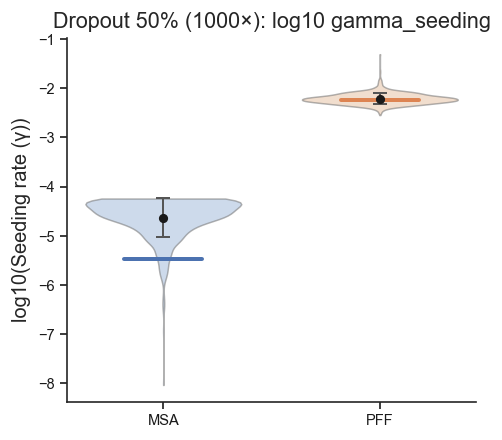

In [8]:
# -------------------------
# Plot log10 gamma-seeding distributions
# -------------------------
for k in ["gamma_seeding"]:
    if (
        PARAMS[k]["col"] not in df_msa.columns
        or PARAMS[k]["col"] not in df_pff.columns
    ):
        print(
            f"[Skip] Missing column "
            f"'{PARAMS[k]['col']}' in one of the sheets."
        )
        continue

    plot_param_violin_log10(k)